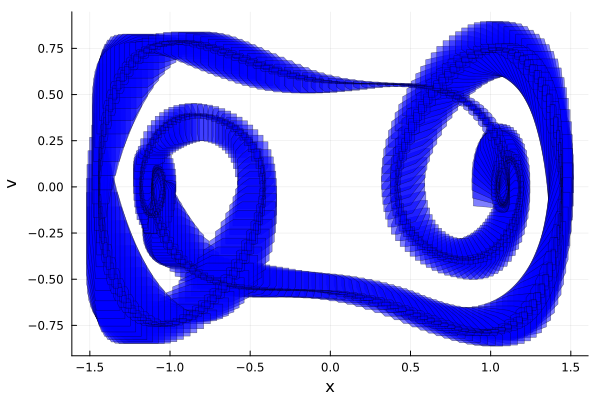

In [1]:
using ReachabilityAnalysis, Plots

const ω = 1.2
const T = 2 * pi / ω

@taylorize function duffing!(du, u, p, t)
    local α = -1.0
    local β = 1.0
    local δ = 0.3
    local γ = 0.37

    x, v = u
    f = γ * cos(ω * t)

    # write the nonlinear differential equations defining the model
    du[1] = u[2]
    du[2] = -α*x - δ*v - β*x^3 + f
end

# set of initial states
X0 = Hyperrectangle(low=[0.9, -0.1], high=[1.1, 0.1])

# formulate the initial-value problem
prob = @ivp(x' = duffing!(x), x(0) ∈ X0, dim=2)

# solve using a Taylor model set representation
sol = solve(prob, tspan=(0.0, 20*T), alg=TMJets21a());

# plot the flowpipe in state-space
plot(sol, vars=(1, 2), xlab="x", ylab="v", lw=0.5, color=:blue)
